
## Academic Integrity and Learning Statement

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


## B. Data Cleaning
Goal: get familiar with the strengths and weaknesses of the data set and prepare it for in-depth analysis. 

We will start by looking at the missing values by solving the following tasks: 
- Are there any duplicated products in the data ? Can you remove them ? What is the shape of the remaining data ? 

The data set contains a lot of missing values:
- Create a table that shows the number and percentage of missing values for all columns (sorted from largest to smallest). 
- Try installing and testing out the missingno library to help visualize where the missing values are in the data frame. 
- Use the 4 lists created in the previous task to create 4 line plots or bar charts that show the percentage of missing values in each list. 

Now that you know the extent of missing values in the data, it is time to address them. Your goal is to keep as much data as possible in your data frame. At each step report how many samples and features remain. 
- remove rows and columns that are completely empty
- Start with the list of unit columns, and check what information they hold. Fill up missing values by using the most frequent value as a proxy for the missing value. 
- As a second strategy fill up the missing values of a column using other columns that hold similar information. Apply this approach on the product_name_en column. Find columns that hold similar information and use them to replace the missing values in product_name_en. Report the number of rows that you filled up. 
- As a third strategy, let’s fill up missing values based on common knowledge. Take the column named iron_per_hundred which has about 30% missing values. One possible explanation for its missing values could be that those products are iron-free (like ice cream). Based on this assumption address the missing values for iron_per_hundred.
- Another strategy for text-based columns is to indicate that some of the fields are missing. For instance, the column ingredients_en has about 10% of missing values. Let’s replace them with the term ingredient_missing.
- Finally, let’s assume that you want to build up your data analysis pipeline based on at least 20,000 rows of non-missing data. This amounts to about 5% of the data set. Your task is to drop the columns that have more than 95% of missing values. What is the shape of the remaining data?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
# Import the data as a pandas DataFrame into your notebook
df = pd.DataFrame(pd.read_pickle("data_385k.pkl", compression="zip"))
df.head(5)

NameError: name 'pd' is not defined

In [3]:
# Are there any duplicated data in the data frame?
print("there are", df.duplicated().sum(), "duplicated rows in the data frame")

there are 10500 duplicated rows in the data frame


In [3]:
# Remove all duplicated rows:
print("old data frame shape:", df.shape)

df = df.drop_duplicates()

# Shape of the remaining data:
print("new data frame shape:", df.shape)

old data frame shape: (385384, 99)
new data frame shape: (374884, 99)


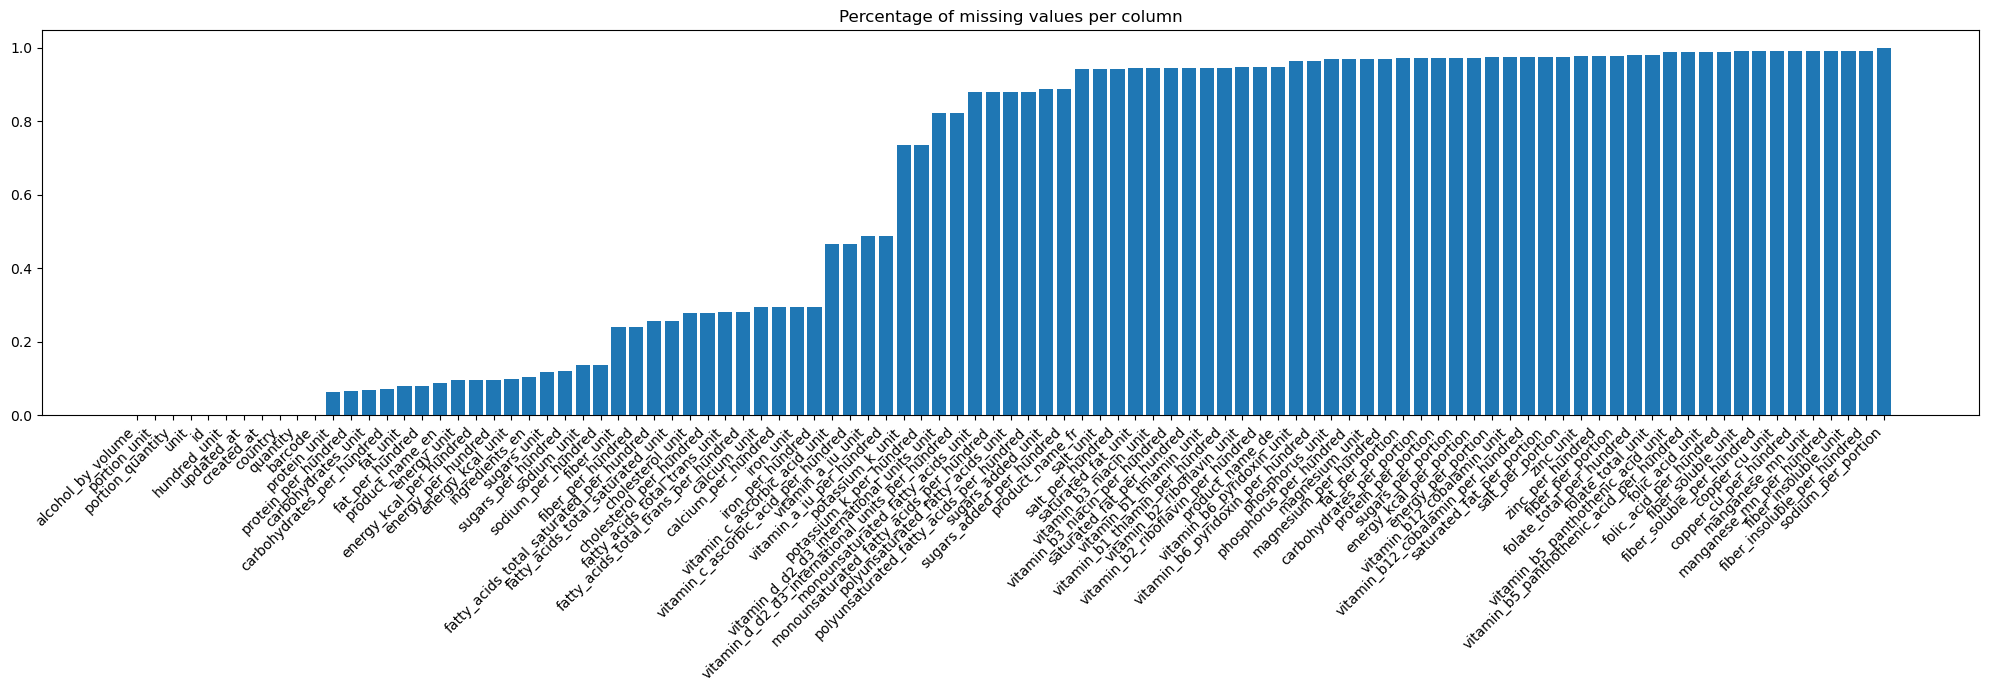

In [5]:
# Are there any missing values in columns ?
# Print the number of missing values and the precentage of missing values for each column
missing = pd.DataFrame(df.isna().sum(), columns=["n_missing"])
missing["percent_missing"] = missing.n_missing / len(df)

# plot the columns sorted according to their percentage of missing values
plt.figure(figsize=(25, 5)) 
plt.bar(x=missing.sort_values("percent_missing").index, height=missing.sort_values("percent_missing").percent_missing)
plt.title("Percentage of missing values per column")
plt.xticks(rotation=45, ha="right")
plt.show()

In [6]:
# Display a table with the missing values for the 25 columns containing the most missing values
missing.sort_values("percent_missing", ascending=False).head(25)

,n_missing,percent_missing
sodium_per_portion,374131,0.997991
fiber_insoluble_per_hundred,371375,0.990640
fiber_insoluble_unit,371374,0.990637
manganese_mn_per_hundred,371350,0.990573
manganese_mn_unit,371347,0.990565
copper_cu_per_hundred,371273,0.990368
copper_cu_unit,371273,0.990368
fiber_soluble_per_hundred,371057,0.989792
fiber_soluble_unit,371055,0.989786
folic_acid_per_hundred,370428,0.988114


### Comments

We observe that there is a very high percentage of missing values for many of the columns. This is something we will need to adress further on.

In [7]:
# Try installing and testing out the missingno library to help visualize where the missing values are in the data frame.
import missingno as msno
%matplotlib inline

In [ ]:
msno.matrix(df)

NameError: name 'missing' is not defined

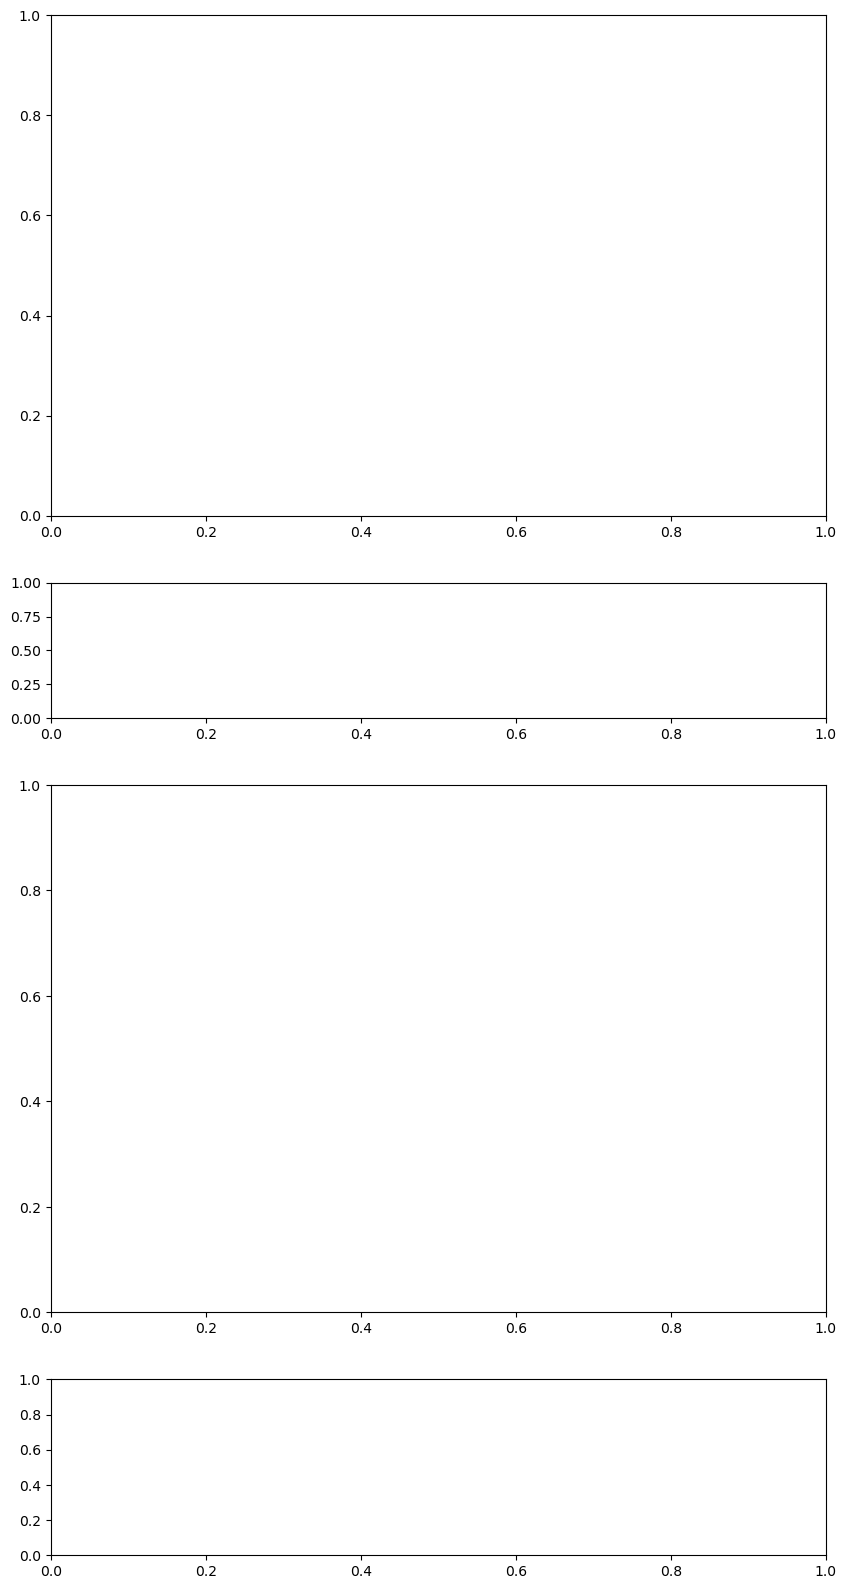

In [4]:
# Use the 4 lists created in the previous task to create 4 line plots or bar charts that show the percentage of missing values in each list. 

# I'm not sure I understood this task correctly. I will make two different graphs to adress the two ways that I understood the task

# Create 3 lists that hold the columns ending with per_hundred, per_portion and _unit and one list that has all the other columns
col_hundred = df.filter(regex="_per_hundred$").columns
col_portion = df.filter(regex="_per_portion$").columns
col_unit = df.filter(regex="_unit$").columns
col_other = [col for col in df.columns if col not in col_hundred and col not in col_portion and col not in col_unit]

# compute the length of each list to allocate the correct size to the subplots:
n0 = len(col_hundred)
n1 = len(col_portion)
n2 = len(col_unit)
n3 = len(col_other)

fig, axes = plt.subplots(4, 1, figsize=(10,20), gridspec_kw={"height_ratios": [n0, n1, n2, n3]})
axes[0].barh(missing.loc[col_hundred, "percent_missing"].sort_values().index, missing.loc[col_hundred, "percent_missing"].sort_values())
axes[1].barh(missing.loc[col_portion, "percent_missing"].sort_values().index, missing.loc[col_portion, "percent_missing"].sort_values())
axes[2].barh(missing.loc[col_unit, "percent_missing"].sort_values().index, missing.loc[col_unit, "percent_missing"].sort_values())
axes[3].barh(missing.loc[col_other, "percent_missing"].sort_values().index, missing.loc[col_other, "percent_missing"].sort_values())

plt.xlabel("percentage of missing values")
fig.suptitle("Percentage of missing values per list", y=0.9)

In [ ]:
# Here, I am making a violin plot for each list with the average percentage of missing values

fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))
sns.set_palette("pastel")
sns.violinplot(data=missing.loc[col_hundred, "percent_missing"], ax=axes[0])
sns.violinplot(data=missing.loc[col_portion, "percent_missing"], ax=axes[1])
sns.violinplot(data=missing.loc[col_unit, "percent_missing"], ax=axes[2])
sns.violinplot(data=missing.loc[col_other, "percent_missing"], ax=axes[3])
axes[0].set_title("per_hundred")
axes[1].set_title("per_portion")
axes[2].set_title("per_unit")
axes[3].set_title("Other")
plt.tight_layout()
fig.suptitle("Percentage of missing values", y=1.1)

#### Comments

We see that, especially in the per_hundred and per_unit columns, there are a lot of missing values. Interestingly, the distribution seems to be similar for those two columns, we could hypothetize that a lot of rows have information neither in the per_hundred nor in the per_unit row.

In [5]:
# Now that you know the extent of missing values in the data, it is time to address them. Your goal is to keep as much data as possible in your data frame. At each step report how many samples and features remain. 
# remove rows and columns that are completely empty

print("data frame shape before removing missing values", df.shape)

df = df.dropna(axis=0, how="all")
df = df.dropna(axis=1, how="all")

print("data frame shape after removing missing values:", df.shape)

data frame shape before removing missing values (374884, 99)
data frame shape after removing missing values: (374884, 99)


#### Comments

We see that this approach didn't remove any rows or columns, as we didn't have any row or column that is completely empty. 

In [6]:
# Start with the list of unit columns, and check what information they hold. 
# Fill up missing values by using the most frequent value as a proxy for the missing value. 

# Get the most frequent value per column
top = df[col_unit].mode(axis=0).iloc[0]

# fill in the missing values: 
df[col_unit] = df[col_unit].fillna(top)

# Make sure that it worked
print("there are now", df[col_unit].isna().sum().sum(), "missing values in the per_unit columns")

there are now 0 missing values in the per_unit columns


In [7]:
# As a second strategy fill up the missing values of a column using other columns that hold similar information. 
# Apply this approach on the product_name_en column. Find columns that hold similar information and use them to replace the missing values in product_name_en. 
# Report the number of rows that you filled up. 

# First calculate the number of rows that are empty:
empty_origin_en = df.product_name_en.isna().sum()
print("originally, there are " , empty_origin_en, "rows that don't have a product name in english")

# We could fill the product_name_en by product_name_fr or product_name_de
df["product_name_en"] = df["product_name_en"].fillna(df["product_name_fr"])
empty_fr = df.product_name_en.isna().sum()
print("Using the french column filled up", empty_origin_en - empty_fr, "rows")

df["product_name_en"] = df["product_name_en"].fillna(df["product_name_de"])
empty_de = df.product_name_en.isna().sum()
print("using the german column filled up", empty_origin_en - empty_de, "rows")

# We see that this is not a good strategy, since not all rows were filled up. 

# An alternative would be to fill this up using the barcode. 
df["product_name_en"] = df["product_name_en"].fillna(df["barcode"])
empty_barcode = df.product_name_en.isna().sum()
print("using the barcode column filled up", empty_origin_en - empty_barcode, "rows")

originally, there are  33165 rows that don't have a product name in english
Using the french column filled up 11619 rows
using the german column filled up 14299 rows
using the barcode column filled up 33165 rows


In [8]:
# As a third strategy, let’s fill up missing values based on common knowledge. 
# Take the column named iron_per_hundred which has about 30% missing values. 
# One possible explanation for its missing values could be that those products are iron-free (like ice cream). 
# Based on this assumption address the missing values for iron_per_hundred.

# Let's replace all missing values with 0 

print("there are originally", df.iron_per_hundred.isna().sum(), "rows without an iron_per_hundred value")

df.iron_per_hundred = df.iron_per_hundred.fillna(value=0)

print("there are now", df.iron_per_hundred.isna().sum(), "rows without an iron_per_hundred value")


there are originally 110495 rows without an iron_per_hundred value
there are now 0 rows without an iron_per_hundred value


In [9]:
# Another strategy for text-based columns is to indicate that some of the fields are missing. 
# For instance, the column ingredients_en has about 10% of missing values. Let’s replace them with the term ingredient_missing.

print("there are originally", df.ingredients_en.isna().sum(), "missing ingredients")

df.ingredients_en = df.ingredients_en.fillna(value="ingredient_missing")

print("there are now", df.iron_per_hundred.isna().sum(), "missing ingredients")


there are originally 38958 missing ingredients
there are now 0 missing ingredients


In [10]:
# Finally, let’s assume that you want to build up your data analysis pipeline based on at least 20,000 rows of non-missing data. 
# This amounts to about 5% of the data set. Your task is to drop the columns that have more than 95% of missing values. 
# What is the shape of the remaining data?

print("original shape:", df.shape)

# Number of missing values that correspond to 95% of rows
threshold_95 = round(0.05*len(df))

#drop those columns
df = df.dropna(axis=1, thresh=threshold_95)

print("new shape:", df.shape)

original shape: (374884, 99)
new shape: (374884, 77)


## C. Preliminary Exploratory Data Analysis (EDA)

Let’s start by exploring the categorical variables in more detail. 

- What is the number of unique values in categorical variables? Show the proportion of samples in each categorical level in the variables country and unit using appropriate visualizations.

For the numerical variables provide descriptive statistics and informative plots (e.g., histograms). Make sure that:
- the statistical values are displayed for all columns,
- the plots are obtained as subplots and are suitably formatted and labelled,
- your discussion links statistics and visualisations and highlights common properties and problems observed.

Note: When using seaborn.histplot() the default setting bins='auto'can lead to very long computations, so instead fix a suitable number of bins upfront.

Errors and unrealistic values are a real problem for the reliability of our results like correlation analyses (part of Task F). Hence part of the preliminary EDA aims to check for such problematic values and address them. 

Using your insights gained from the statistics and your plots of the per_hundred columns, your task is to identify and address the problematic values in these columns. Afterwards re-run the descriptive statistics and plots to verify everything is ok now.

Below are some additional tips and hints.
- Work with the lists of columns ending in per_hundred and _unit. Each nutrient should have an associated per_hundred-column and a _unit-column.
- The range of acceptable values in each per_hundred-column depends on the unit given in the associated _unit-column. For example, the unit for the protein_per_hundred column is g (as given by the protein_unit column). Thus the values in the protein_per_hundred column should range between 0 and 100. If a column’s unit is mg, then the values should range between 0 and 105. If a column’s unit is in International units (IU), you can use the “Mass equivalents of 1 IU” indicated on this Wikipedia page to define an upper threshold value.

Unit 	Range of values 	Source
g 	[0, 100] 	-
mg 	[0, 105
] 	-
µg 	[0, 108
] 	-
kJ 	[0, 3700] 	(Wikipedia)
kCal 	[0, 885] 	(Wikipedia)
1 IU Vitamin A 	[0, 3.3×108
] 	(Wikipedia)
1 IU Vitamin D 	[0, 4×109
] 	(Wikipedia)

Columns in our data set may be related to each other or pose constraints on one another. Unfortunately, this may also give rise to inconsistencies. Your task is to investigate the three cases below analytically (including visualizations like scatterplots), identify potential inconsistencies and address them. You should allow for some rounding errors and verify that your approaches have addressed the issues appropriately.
- The bulk of most products is made up of the four main macronutrients (fat, protein, carbohydrates and fiber). In the previous subtask we checked that each of their "_per_hundred"-value is at most 100g. We can equally apply the same logic for their combined amount. For example, a product with 64g of carbohydrates, 43g of protein and 12g of fat would give us a total of 119g of macronutrients in 100g of produce. Clearly that is not realistic.
- The column "energy_per_hundred" measures the energy content in kJ. Analyze its relationship with the column "energy_kcal_per_hundred".
- Each of the four macronutrients has a specific energy content (fat 37 kJ/g, protein and carbohydrates 17 kJ/g, fibre 8 kJ/g). Calculate the energy provided by these four macronutrients and compare this to the "energy_per_hundred"-column. Keep in mind that we are only looking at a subset of all the nutrients.

Despite removing recording errors from the per_hundred columns, some of them still contain “extreme” values, which are distinct from the rest of the data points. Your goal is to pick a few variables from the per_hundred list and address outliers. Be mindful that some outlier detection approaches are not reliable when the underlying variables are strongly skewed.

Save the cleaned data as a new pickle file and make sure to use this cleaned data for Task F and Task G later on. 

In [ ]:
# What is the number of unique values in categorical variables ?
# Show the proportion of samples in each categorical level in the variables country and unit using appropriate visualization

df.dtypes

# Find the levels in the variable country
print(df["country"].value_counts())

# Find the levels in the variable unit
print(df["unit"].value_counts())

In [ ]:
# Proportion of samples in each categorical level for the variable country:
proportion_country = df.groupby("country").size()/len(df["country"])

# Alternative:
proportion_country = df["country"].value_counts(normalize=True)

# Proportion of samples in each categorical level for the variable unit:
proportion_unit = df["unit"].value_counts(normalize=True)

fig, axes = plt.subplots(1,2, figsize=(10,3))

proportion_country.plot.barh(ax=axes[0])
axes[0].set_title("Proportion per country")
proportion_unit.plot.barh(ax=axes[1])
axes[1].set_title("Proportion per unit")

## Interpretation of the graphs

We observe that a large majority of the entries are listed as having US as their country. Interestingly, the vast majorities of items are listed in grams (metric system). 

In [11]:
# For the numerical variables provide descriptive statistics and informative plots (e.g., histograms). Make sure that:
# the statistical values are displayed for all columns,
# the plots are obtained as subplots and are suitably formatted and labelled,
# your discussion links statistics and visualisations and highlights common properties and problems observed.

num_col = df.select_dtypes(include=["float64", "int64"]).columns

In [12]:
# Start by displaying statistics for the different columns
df[num_col].describe()

,alcohol_by_volume,calcium_per_hundred,carbohydrates_per_hundred,cholesterol_per_hundred,energy_kcal_per_hundred,energy_per_hundred,fat_per_hundred,fatty_acids_total_saturated_per_hundred,fatty_acids_total_trans_per_hundred,fiber_per_hundred,...,saturated_fat_per_hundred,sodium_per_hundred,sugars_added_per_hundred,sugars_per_hundred,vitamin_a_iu_per_hundred,vitamin_b1_thiamin_per_hundred,vitamin_b2_riboflavin_per_hundred,vitamin_b3_niacin_per_hundred,vitamin_c_ascorbic_acid_per_hundred,vitamin_d_d2_d3_international_units_per_hundred
count,374884.000000,264854.000000,348551.000000,270282.000000,338574.000000,338571.000000,345260.000000,279151.000000,269607.000000,284479.000000,...,20910.000000,323824.000000,42478.000000,330154.000000,192093.000000,20402.000000,19683.000000,21117.000000,200006.000000,67024.000000
mean,0.027911,116.647405,34.005231,58.981358,272.484231,1139.512786,12.705385,4.943331,0.034861,2.925621,...,5.904191,1.402169,23.993521,16.992009,494.236708,0.925326,1.680103,9.846486,15.704688,14.186515
std,0.769066,2557.910159,40.848987,1934.718972,258.287614,1079.676340,19.508870,8.500435,1.285369,5.892698,...,8.314095,69.838205,25.616094,31.176491,2445.251154,13.490207,142.610273,73.079281,583.641608,73.262518
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,6.670000,0.000000,89.000000,372.380000,0.000000,0.000000,0.000000,0.000000,...,0.500000,0.030000,5.200000,1.670000,0.000000,0.000000,0.200000,3.000000,0.000000,0.000000
50%,0.000000,36.000000,23.530000,0.000000,267.000000,1117.130000,5.450000,2.000000,0.000000,1.600000,...,2.000000,0.260000,16.000000,6.450000,0.000000,0.000000,0.330000,4.880000,0.000000,0.000000
75%,0.000000,102.000000,60.000000,25.000000,400.000000,1673.600000,20.000000,7.140000,0.000000,3.600000,...,9.000000,0.570000,36.600000,25.140000,352.000000,1.000000,0.590000,8.330000,3.900000,0.000000
max,57.900000,684000.000000,6400.000000,250000.000000,39600.000000,165686.400000,3200.000000,1000.000000,615.380000,1730.000000,...,100.000000,25833.330000,1100.000000,5800.000000,333333.000000,1111.000000,20000.000000,6785.710000,210000.000000,5000.000000


#### Comments

We observe several things:
- For alcohol_by_volume: most values are 0 (most items don't contain alcohol), with a very low mean and a high standard deviation. In this case, it would maybe make sense to plot only the columns containing alcohol. 
- the ID column is a numerical column (it contains numbers) but acts more as a categorical variable. It wouldn't make sense to plot a histogram here. 
- Similar to alcohol_by_volume, a lot of the per_hundred columns have a very high amount of values that are at 0. It will be difficult to plot them all, perhaps a solution would be to plot only the values above 0. 
- the column quantity seems to have a more interesting distribution, in this case making a boxplot would make sense. However, it seems to also have outliers (the max is at 230000 which seems too high). 

/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Text(0.5, 1.05, 'Boxplots for all numerical columns')

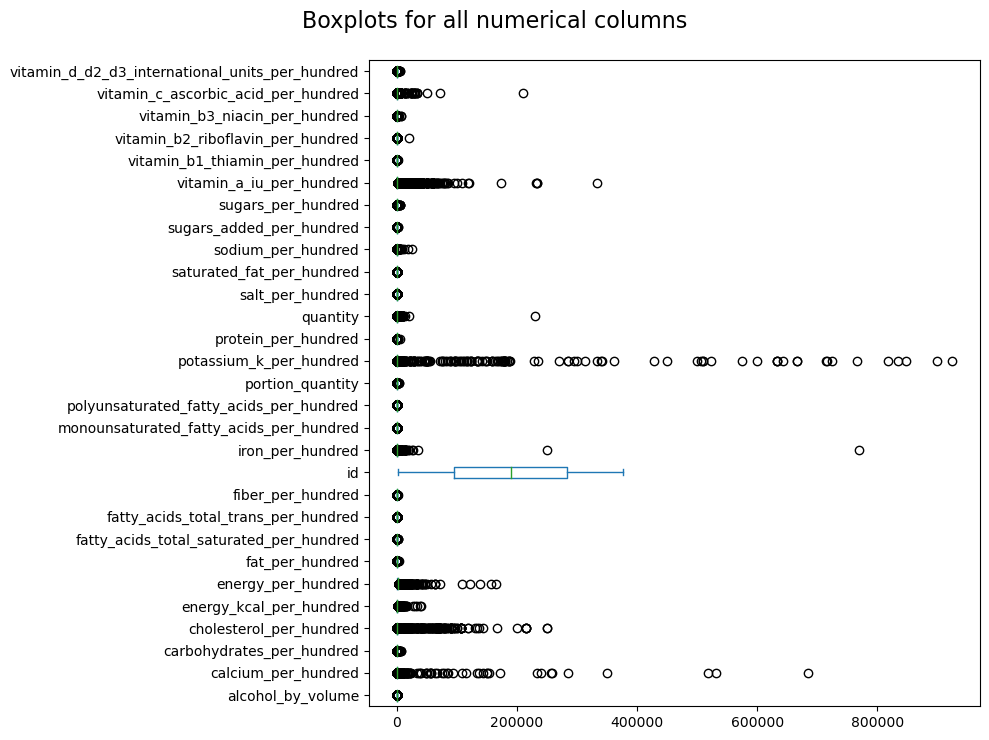

In [13]:
# First create boxplot for each column (will display the statistical values)
df[num_col].plot.box(figsize=(10,7), vert=False)
plt.tight_layout()
plt.suptitle("Boxplots for all numerical columns", y=1.05, size=16)

#### Comments
As expected, the boxplots do not make a lot of sense for most of these variables. We do however observe that there are very clear outliers for several of the per_hundred columns that we could remove.

Text(0.5, 1.02, 'Histograms for all numerical columns')

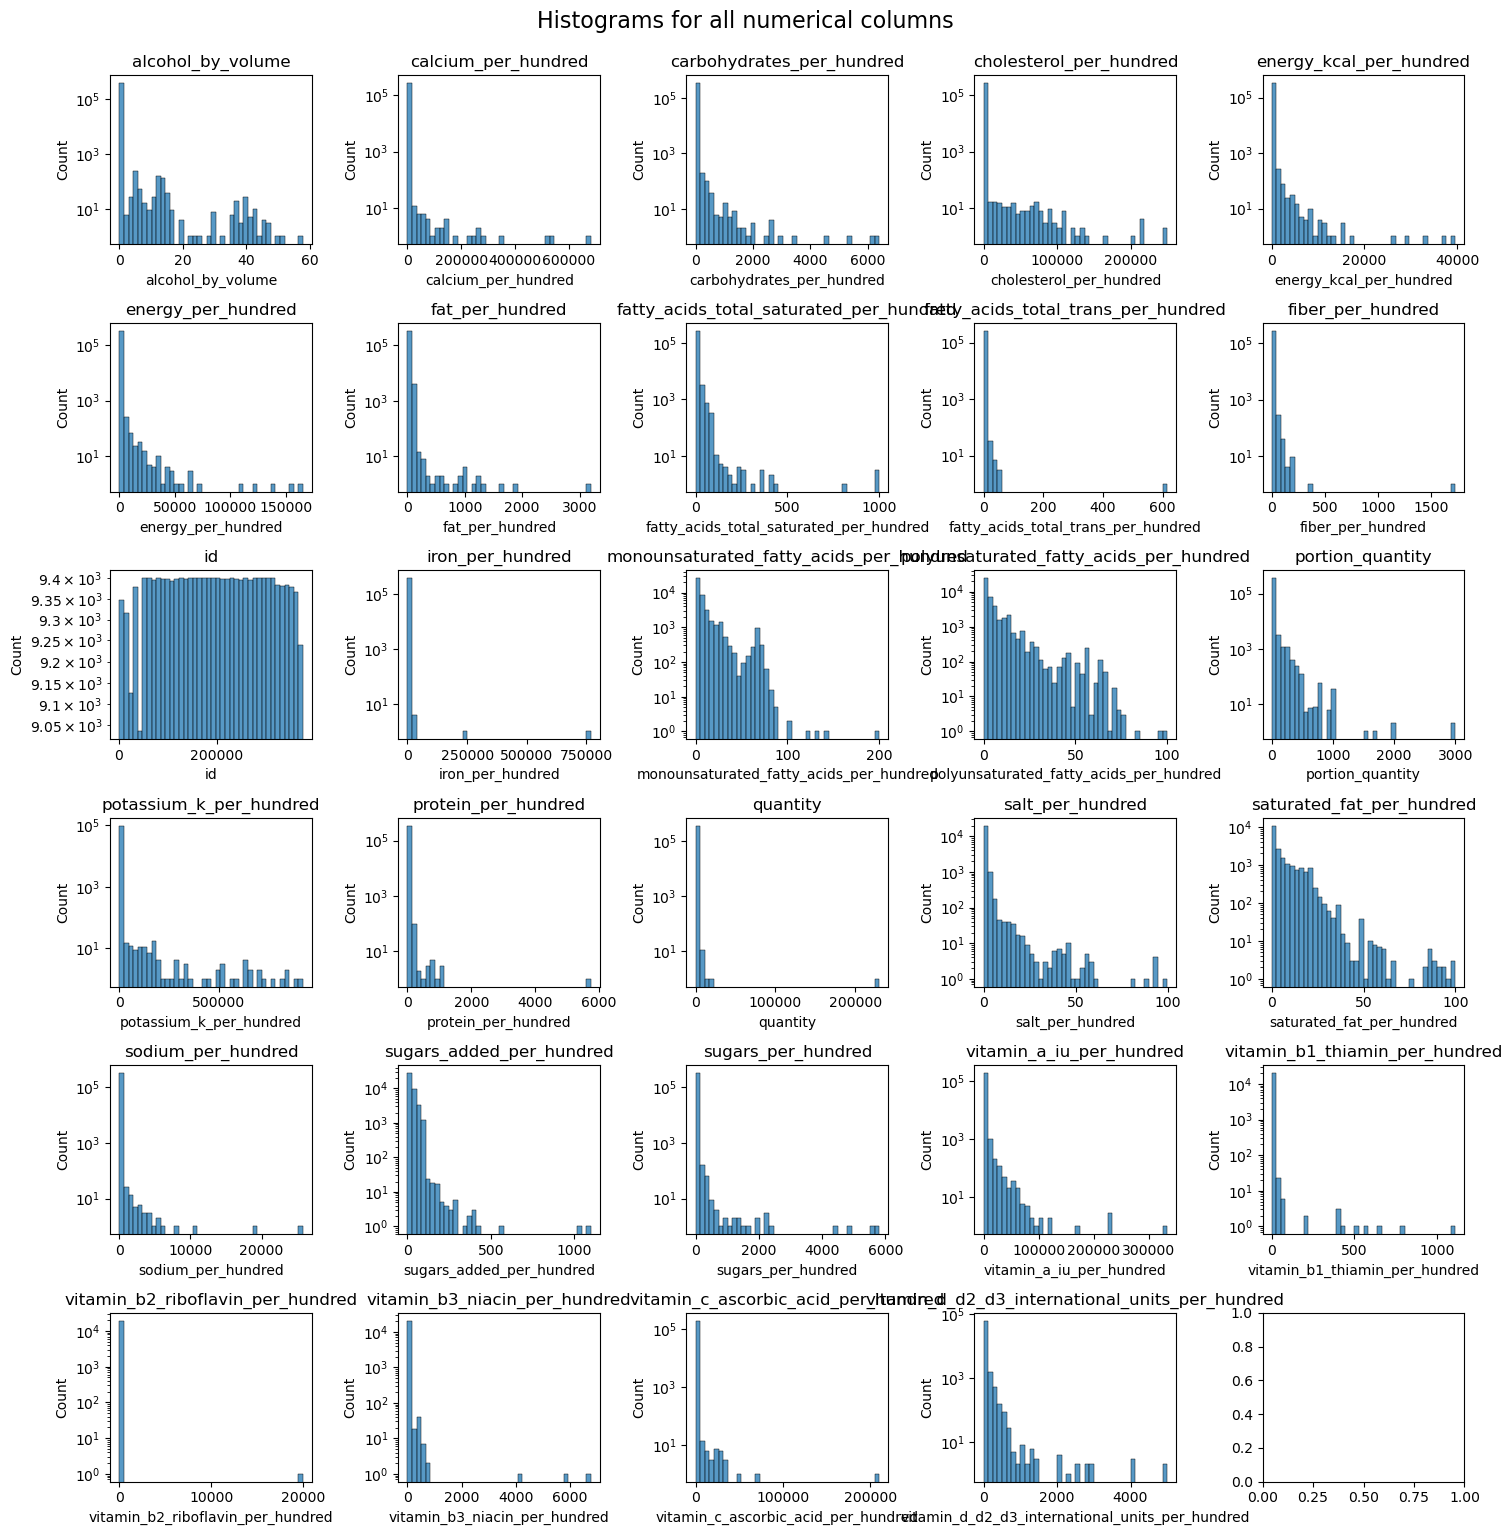

In [14]:
# We can also plot histograms to see the information in a different way

fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.histplot(df[col], ax=ax, bins=40)
    ax.set_title(col)
    ax.set_yscale("log")


plt.tight_layout()
plt.suptitle("Histograms for all numerical columns", y=1.02, size=16)

#### Comments

These plots also highlight that the majority of the data in several columns is close to zero. Additionally, any outliers skew the histograms rendering the visualization complicated. Setting the y scale to a log scale helps with the visualization.

let's replot the data with all values above zero to have a better understanding of the distributions

NameError: name 'df_clean' is not defined

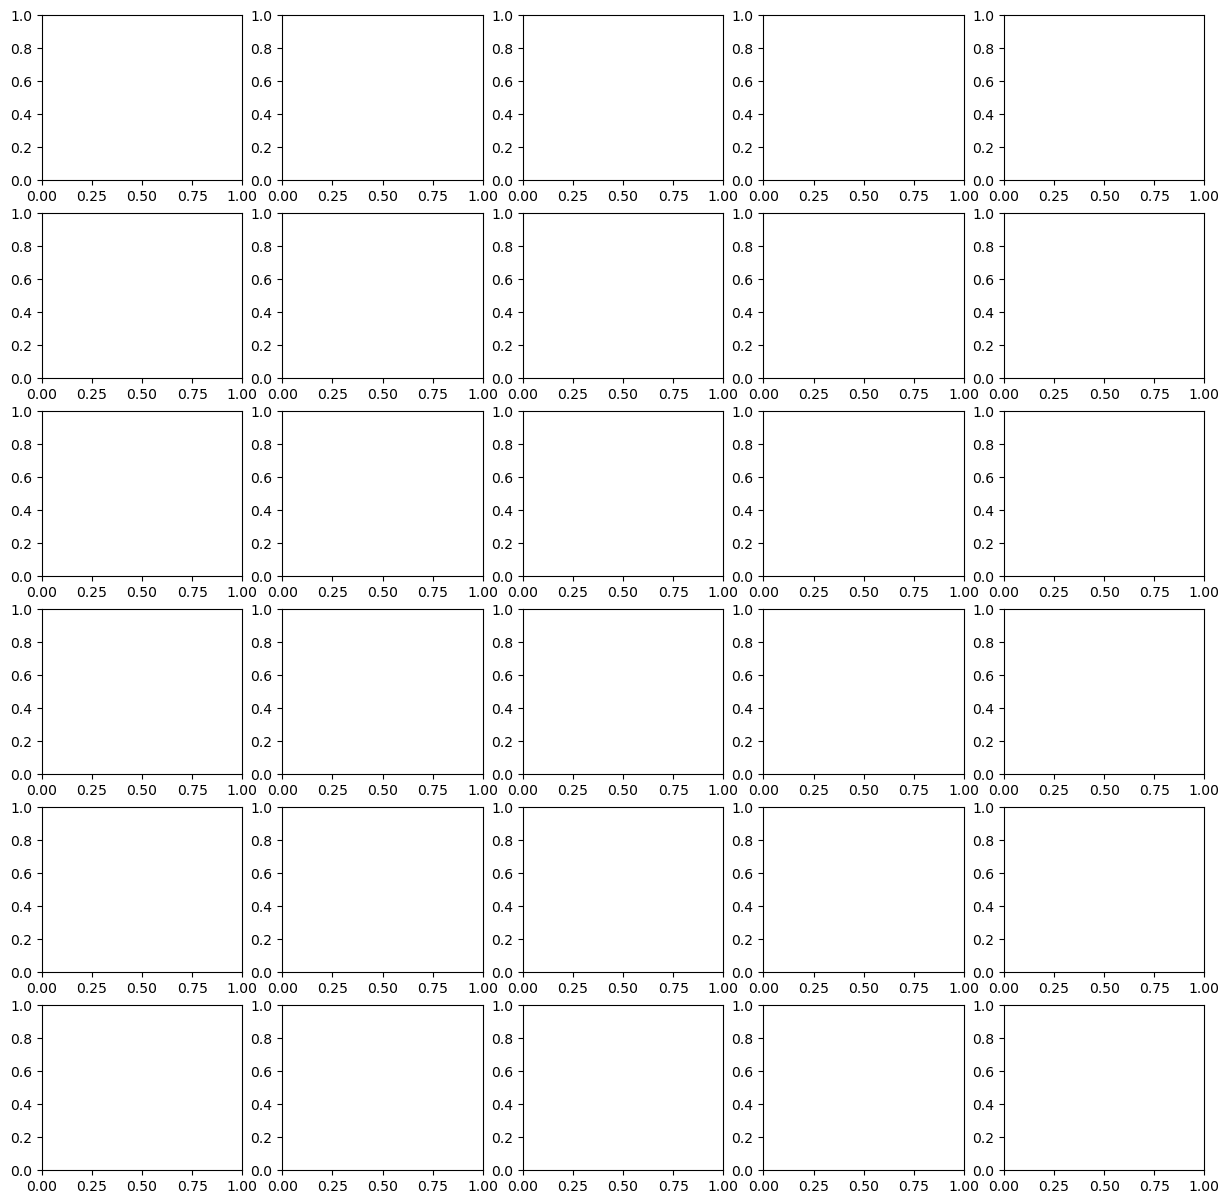

In [15]:
fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.histplot(df.loc[(df[col]!=0), col], ax=ax, bins=40)
    ax.set_title(col)
    ax.set_yscale("log")


plt.tight_layout()
plt.suptitle("Histograms for all numerical columns >0", y=1.02, size=16)

We still observe that there are a lot of outliers in the data.

We could start by removing outliers using a z-score. However, we need to take into account that the distribution is not standard for most of the values, as there are many values that are equal to 0. A strategy could be to calculate a z score using only the values different then 0. 

In [16]:
# removing outliers
# Let's remove the column ID that isn't a real numerical column

num_col = [col for col in num_col if col != "id"]

# Calculating a z-score
z_filter = pd.DataFrame(index=df.index)

# Create the filter and print how many outliers we would delete if we use this method
# Use only the values above 0 for the calculation of the z score
# Flag a row if the value is an outlier but don't flag NaN values as they are not wrong per se
for col in num_col:
    mean_0 = df.loc[df[col] > 0, col].mean(axis=0)
    std_0 = df.loc[df[col] > 0, col].std(axis=0)
    z_filter[col] = (np.abs(df[col] - mean_0) > (3 * std_0)) & df[col].notna()
    print(col, z_filter[col].sum())

alcohol_by_volume 11
calcium_per_hundred 65
carbohydrates_per_hundred 390
cholesterol_per_hundred 173
energy_kcal_per_hundred 407
energy_per_hundred 389
fat_per_hundred 4068
fatty_acids_total_saturated_per_hundred 1450
fatty_acids_total_trans_per_hundred 12
fiber_per_hundred 2255
iron_per_hundred 35
monounsaturated_fatty_acids_per_hundred 1605
polyunsaturated_fatty_acids_per_hundred 969
portion_quantity 122
potassium_k_per_hundred 111
protein_per_hundred 1088
quantity 430
salt_per_hundred 200
saturated_fat_per_hundred 251
sodium_per_hundred 152
sugars_added_per_hundred 96
sugars_per_hundred 330
vitamin_a_iu_per_hundred 817
vitamin_b1_thiamin_per_hundred 15
vitamin_b2_riboflavin_per_hundred 1
vitamin_b3_niacin_per_hundred 65
vitamin_c_ascorbic_acid_per_hundred 108
vitamin_d_d2_d3_international_units_per_hundred 75


#### Comments:
This method seems rather conservative and not be removing too many outliers. Let's keep this filter as it is right now (even though I do realize that it might not be the best filter as a lot of the values are not normally distributed).  

In [17]:
# Let's now define another filter with a maximal value allowed depending on the unit. 
# This is for the columns per_hundred

# Extract the name of the per_hundred column without the _per_hundred
col_hundred_clean = df.filter(regex="_per_hundred").columns
names = col_hundred_clean.str.replace('_per_hundred', '', regex=False)

# Initialize the filter
unit_filter = pd.DataFrame(index=df.index)

# for each name in the list, first find the max limit (min limit is always 0) 
# see if the value in the df_clean is between 0 and the max limit. if not, flag the row.
# don't flag NaN values as they are not wrong per se
for name in names:
    name_hundred = name + "_per_hundred"
    name_unit = name + "_unit"
    max_limit = df[name_unit].map({
    "g": 100,
    "mg": 100_000,
    "µg": 100_000_000,
    "kJ": 3_700,
    "kCal": 885,
    "IU": 4_000_000_000,
})
    unit_filter[name_hundred] = ~(df[name_hundred].between(0, max_limit)) & df[name_hundred].notna()
    print(name_hundred, unit_filter[name_hundred].sum())


calcium_per_hundred 18
carbohydrates_per_hundred 1076
cholesterol_per_hundred 22
energy_kcal_per_hundred 888
energy_per_hundred 829
fat_per_hundred 136
fatty_acids_total_saturated_per_hundred 32
fatty_acids_total_trans_per_hundred 1
fiber_per_hundred 21
iron_per_hundred 2
monounsaturated_fatty_acids_per_hundred 4
polyunsaturated_fatty_acids_per_hundred 0
potassium_k_per_hundred 81
protein_per_hundred 172
salt_per_hundred 0
saturated_fat_per_hundred 0
sodium_per_hundred 188
sugars_added_per_hundred 96
sugars_per_hundred 443
vitamin_a_iu_per_hundred 0
vitamin_b1_thiamin_per_hundred 0
vitamin_b2_riboflavin_per_hundred 0
vitamin_b3_niacin_per_hundred 0
vitamin_c_ascorbic_acid_per_hundred 1
vitamin_d_d2_d3_international_units_per_hundred 0


In [18]:
# Now filter out all the values based on the z filter and the unit filter
# For both z_filter and unit_filter, if the value is true, it means the value was flaged and should be removed.

# I want to remove any row where a value has been flagged. 
# To do so, I will create a row filter.
row_filter = unit_filter.any(axis=1) | z_filter.any(axis=1)
print(row_filter.sum(), "rows will be removed as they contain a flaged value")

df_filtered = df[~row_filter]

print("Before filtering, the data frame shape was:", df.shape)
print("After filtering, the data frame shape is:", df_filtered.shape)

11666 rows will be removed as they contain a flaged value
Before filtering, the data frame shape was: (374884, 77)
After filtering, the data frame shape is: (363218, 77)


Text(0.5, 1.02, 'Histograms for all numerical columns >0')

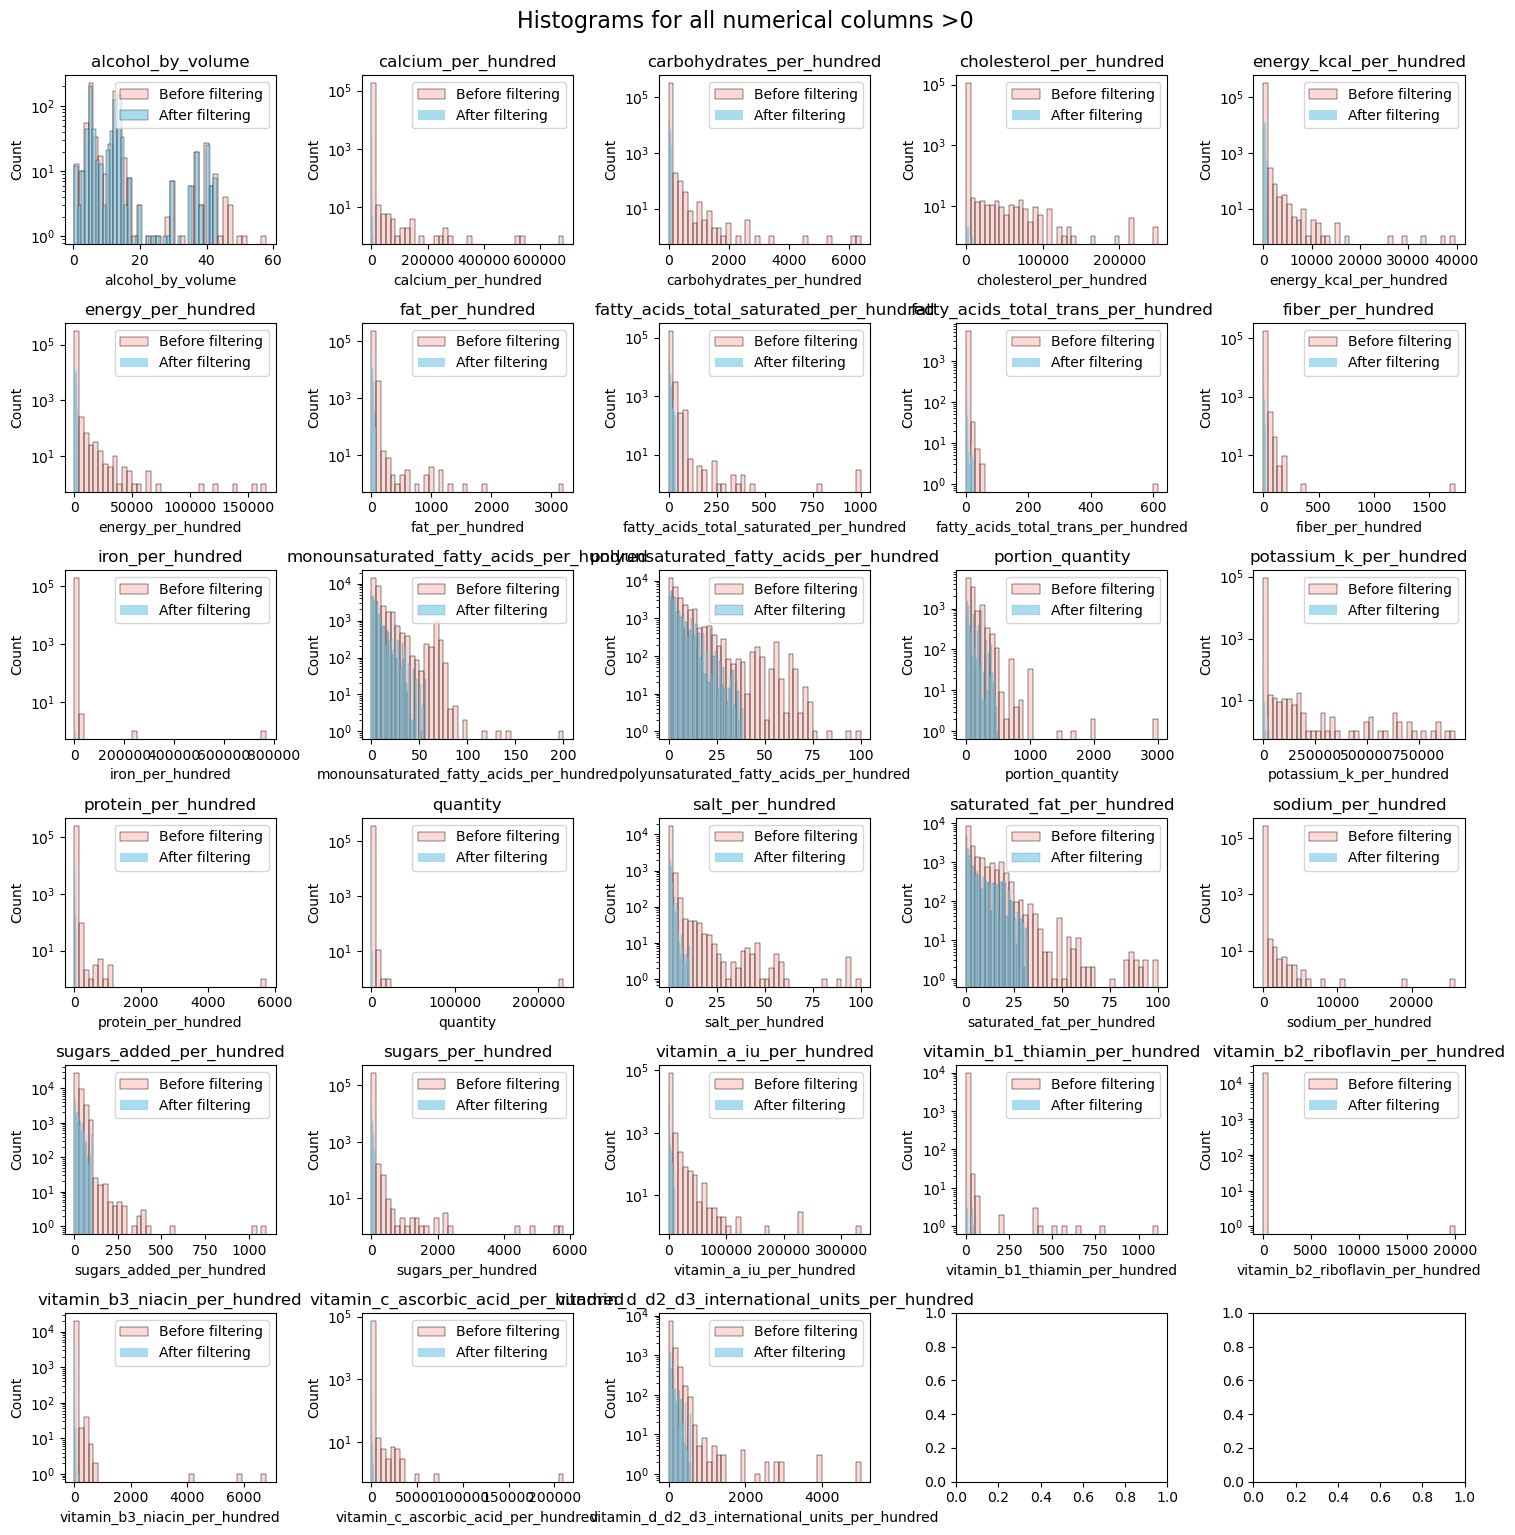

In [19]:
# Let's plot the data after and before filtering
fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    # Before filtering
    sns.histplot(df.loc[df[col] > 0, col],
                 ax=ax, bins=40, color="salmon", alpha=0.3, label="Before filtering")
    
    # After filtering
    sns.histplot(df_filtered.loc[df_filtered[col] > 0, col],
                 ax=ax, bins=40, color="skyblue", alpha=0.7, label="After filtering")
    
    ax.set_title(col)
    ax.set_yscale("log")
    ax.legend()


plt.tight_layout()
plt.suptitle("Histograms for all numerical columns >0", y=1.02, size=16)

#### Comments

We observe that we did remove some of the outliers and extreme values for most columns. Interestingly, there are some columns (such as calcium and carbohydrate) were it seems that most values were removed. We can replot only the filtered values to inspect this in more detail

In [ ]:
# Let's plot the data only after filtering
fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.histplot(df_filtered.loc[df_filtered[col] > 0, col],
                 ax=ax, bins=40, color="skyblue", alpha=0.7, label="After filtering")
    
    ax.set_title(col)
    ax.set_yscale("log")
    ax.legend()


plt.tight_layout()
plt.suptitle("Histograms for all numerical columns >0", y=1.02, size=16)

#### Comments

This confirms what we saw before, some columns likely contained mistakes (wrong units) and were filtered out. This is especially the case for the calcium and carbohydrate columns for instance. 

Columns in our data set may be related to each other or pose constraints on one another. Unfortunately, this may also give rise to inconsistencies. Your task is to investigate the three cases below analytically (including visualizations like scatterplots), identify potential inconsistencies and address them. You should allow for some rounding errors and verify that your approaches have addressed the issues appropriately.
- The bulk of most products is made up of the four main macronutrients (fat, protein, carbohydrates and fiber). In the previous subtask we checked that each of their "_per_hundred"-value is at most 100g. We can equally apply the same logic for their combined amount. For example, a product with 64g of carbohydrates, 43g of protein and 12g of fat would give us a total of 119g of macronutrients in 100g of produce. Clearly that is not realistic.
- The column "energy_per_hundred" measures the energy content in kJ. Analyze its relationship with the column "energy_kcal_per_hundred".
- Each of the four macronutrients has a specific energy content (fat 37 kJ/g, protein and carbohydrates 17 kJ/g, fibre 8 kJ/g). Calculate the energy provided by these four macronutrients and compare this to the "energy_per_hundred"-column. Keep in mind that we are only looking at a subset of all the nutrients.

In [1]:
# Transform all values in gram

col_hundred_filtered = pd.Series(['carbohydrates_per_hundred','fat_per_hundred',
                              'fiber_per_hundred', 'protein_per_hundred'])

names = col_hundred_filtered.str.replace('_per_hundred', '', regex=False)

gram = pd.DataFrame(columns = names, index=df_filtered.index) 

# for each name in the list, compute the value in grams
for name in names:
    name_hundred = name + "_per_hundred"
    name_unit = name + "_unit"
    gram[name] = df_filtered[name_hundred] / df_filtered[name_unit].map({
        "g": 1,
        "mg": 1000,
        "µg": 1000_000
    })

gram

NameError: name 'pd' is not defined

In [ ]:
# Plot the total macronutrient content in a histogram 

fig, axes = plt.subplots(3,2, figsize=(10, 10))

axes[0,0].hist(gram.sum(axis=1), bins=50)
axes[0,0].set_xlabel("Sum of macronutrients (g per 100g)")
axes[0,0].set_ylabel("Number of products")
axes[0,0].set_title("Distribution of total macronutrient content")

axes[0,1].hist(gram.carbohydrates, bins=50)
axes[0,1].set_xlabel("Sum of macronutrients (g per 100g)")
axes[0,1].set_ylabel("Number of products")
axes[0,1].set_title("Distribution of carbohydrate content")

axes[1,0].hist(gram.protein, bins=50)
axes[1,0].set_xlabel("Sum of macronutrients (g per 100g)")
axes[1,0].set_ylabel("Number of products")
axes[1,0].set_title("Distribution of protein content")

axes[1,1].hist(gram.fat, bins=50)
axes[1,1].set_xlabel("Sum of macronutrients (g per 100g)")
axes[1,1].set_ylabel("Number of products")
axes[1,1].set_title("Distribution of fat content")

axes[2,0].hist(gram.fiber, bins=50)
axes[2,0].set_xlabel("Sum of macronutrients (g per 100g)")
axes[2,0].set_ylabel("Number of products")
axes[2,0].set_title("Distribution of fiber content")

plt.tight_layout()
plt.show()

#### Comments
We see on the first histogram that a small percentage of rows have a total macronutrient content that is above 100. This is likely due to an error in the total carbohydrate content, as there seems to be a lot of values that are around 100.

In [21]:
# Create a filter to remove all collumns with the sum of macronutrients being > 100

filter_macronutrients = gram.sum(axis=1) > 100.5

print(filter_macronutrients.sum(), "rows are incorrect")

print("data frame shape before removing rows", df_filtered.shape)

df_filtered = df_filtered[~filter_macronutrients]

print("data frame shape after removing rows", df_filtered.shape)

19524 rows are incorrect
data frame shape before removing rows (363218, 77)
data frame shape after removing rows (343694, 77)


Text(0.5, 1.0, 'relationship between kj and kcal')

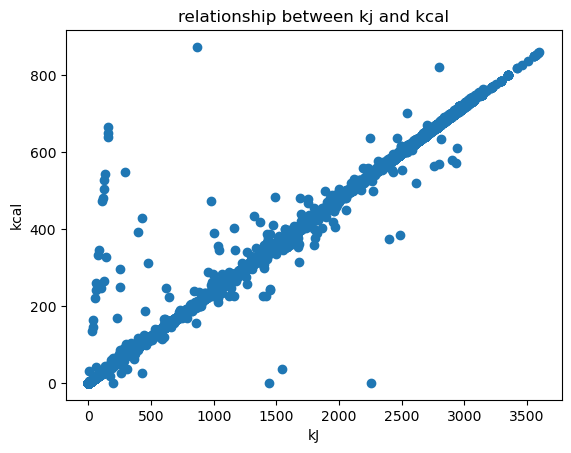

In [22]:
#The column "energy_per_hundred" measures the energy content in kJ. 
# Analyze its relationship with the column "energy_kcal_per_hundred".

#Let's plot a scatter plot. The relationship between the two columns should be linear

plt.scatter(df_filtered["energy_per_hundred"], df_filtered["energy_kcal_per_hundred"])
plt.xlabel("kJ")
plt.ylabel("kcal")
plt.title("relationship between kj and kcal")

#### Comments

We see that the majority of values are as expected (i.e., linear relationship between energy in kcal and energy in kj). However, there are some values that divert from the line. We should remove them. 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7,3))

axes[0].hist(df_filtered.energy_per_hundred, bins=20)
axes[0].set_title("energy in kJ")
axes[1].hist(df_filtered.energy_kcal_per_hundred, bins=20)
axes[1].set_title("energy in kcal")

#### Comments

I use this graph as a sanity check, to make sure that the energy in kJ is 4.184 bigger then the energy in kcal

In [23]:
filter_calories = abs(df_filtered["energy_per_hundred"] - 4.184 * df_filtered["energy_kcal_per_hundred"]) > 0.1

print(filter_calories.sum(), "values are incorrect")

print("df shape before filtering:", df_filtered.shape)

df_filtered = df_filtered[~filter_calories]

print("df shape after filtering:", df_filtered.shape)

21991 values are incorrect
df shape before filtering: (343694, 77)
df shape after filtering: (321703, 77)


In [ ]:
# Let's plot the relationship between the two variables again
plt.scatter(df_filtered["energy_per_hundred"], df_filtered["energy_kcal_per_hundred"])
plt.xlabel("kJ")
plt.ylabel("kcal")
plt.title("relationship between kj and kcal")


#### Comments

We see that the relationship is now perfectly linear and that we removed any incorrect values

In [24]:
# Each of the four macronutrients has a specific energy content (fat 37 kJ/g, protein and carbohydrates 17 kJ/g, fibre 8 kJ/g). 
# Calculate the energy provided by these four macronutrients and compare this to the "energy_per_hundred"-column. 
# Keep in mind that we are only looking at a subset of all the nutrients.

macronutrients = pd.Series(["fat_per_hundred", "protein_per_hundred", "carbohydrates_per_hundred", "fiber_per_hundred"])

energy_macronutrients = pd.DataFrame(index=df_filtered.index, columns=macronutrients.str.replace('_per_hundred', '', regex=False))

total_energy = df_filtered[macronutrients].apply({
    "fat_per_hundred": lambda x: x*37,
    "protein_per_hundred": lambda x: x*17,
    "carbohydrates_per_hundred": lambda x: x*17,
    "fiber_per_hundred": lambda x: x*8    
}).sum(axis=1)

In [ ]:
plt.scatter(total_energy, df_filtered["energy_per_hundred"])
plt.title("total energy of all macronutrients vs reported total energy in kJ")
plt.xlabel("energy macro")
plt.ylabel("total energy in kJ")

In [25]:
# now create a filter, the total energy in the macronutrients should be smaller than the energy_per_hundred

filter_energy = (total_energy < (df_filtered["energy_per_hundred"] + 0.1))

print(filter_energy.sum(), "values are incorrect and contain too much macronutrient energy")

print("shape before filtering", df_filtered.shape)

df_filtered = df_filtered[~filter_energy]

print("shape after filtering", df_filtered.shape)

98484 values are incorrect and contain too much macronutrient energy
shape before filtering (321703, 77)
shape after filtering (223219, 77)


In [26]:
# Save new data frame as data_clean

df_filtered.to_csv("data_clean.csv", index=False)